# Example plots to visualize non-inferiority tests

In [140]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

colours = {'poppy':'#ff424b',
           'lady_bug':'#be311e',
           'berry':'#8f2011',
           'maroon':'#730e04',
           'mahogany':'#4a0004'}

def vline(x, top, bottom=0):
    return [x, x], [bottom, top]

In [141]:
def nhst(ax, MEAN, STD, FROM, TO, alpha = 0.05, title=''):
    N = 1000

    def pdf(x):
        return stats.norm.pdf(x, MEAN, STD)

    x = np.arange(FROM, TO, 2*abs(FROM-TO)/N)
    y = pdf(x)

    x_sig_l = stats.norm.ppf(alpha/2, MEAN, STD)
    x_sig_r = stats.norm.ppf(1-alpha/2, MEAN, STD)

    # significance areas
    ax.plot(*vline(x_sig_l, pdf(x_sig_l)), linewidth=2, color=colours['mahogany'])
    fill = np.arange(FROM, x_sig_l, 0.01)
    ax.fill_between(fill, pdf(fill), color=colours['poppy'], alpha=0.75)

    ax.plot(*vline(x_sig_r, pdf(x_sig_r)), linewidth=2, color=colours['mahogany'])
    fill = np.arange(x_sig_r, TO, 0.01)
    ax.fill_between(fill, pdf(fill), color=colours['poppy'], alpha=0.75)

    # bell curve
    ax.plot(x, y, color=colours['maroon'], linewidth=4)

    # labels
    ax.set_xlabel('x')
    ax.set_title(title)

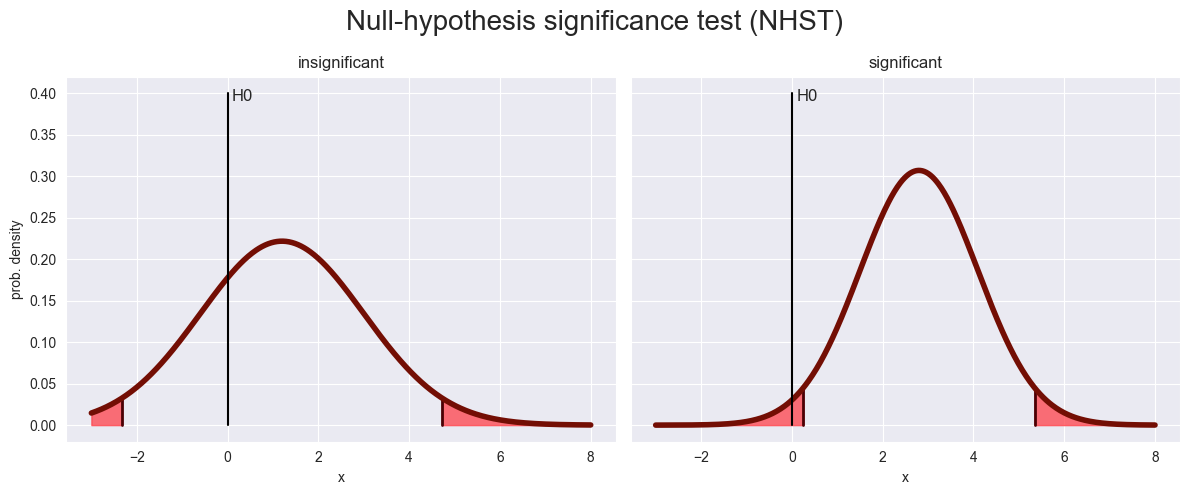

In [142]:
# NHST plots
fig, axs = plt.subplots(ncols=2, figsize=(12,5), sharey=True)
height = 0.4

nhst(axs[0], 1.2, 1.8, -3, 8, title='insignificant')
nhst(axs[1], 2.8, 1.3, -3, 8, title='significant')

# vertical lines at 0
for ax in axs:
    ax.plot(*vline(0, height), c='k')
    ax.text(0.1, height-0.01, 'H0', fontsize=12)


axs[0].set_ylabel('prob. density')

fig.suptitle('Null-hypothesis significance test (NHST)', fontsize=20)

plt.tight_layout()
plt.savefig('examples/nhst.png', transparent=True, dpi=300)

for i, ax in enumerate(axs):
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f'examples/nhst_part{i+1}.png', bbox_inches=extent, transparent=True, dpi=300)

plt.show()

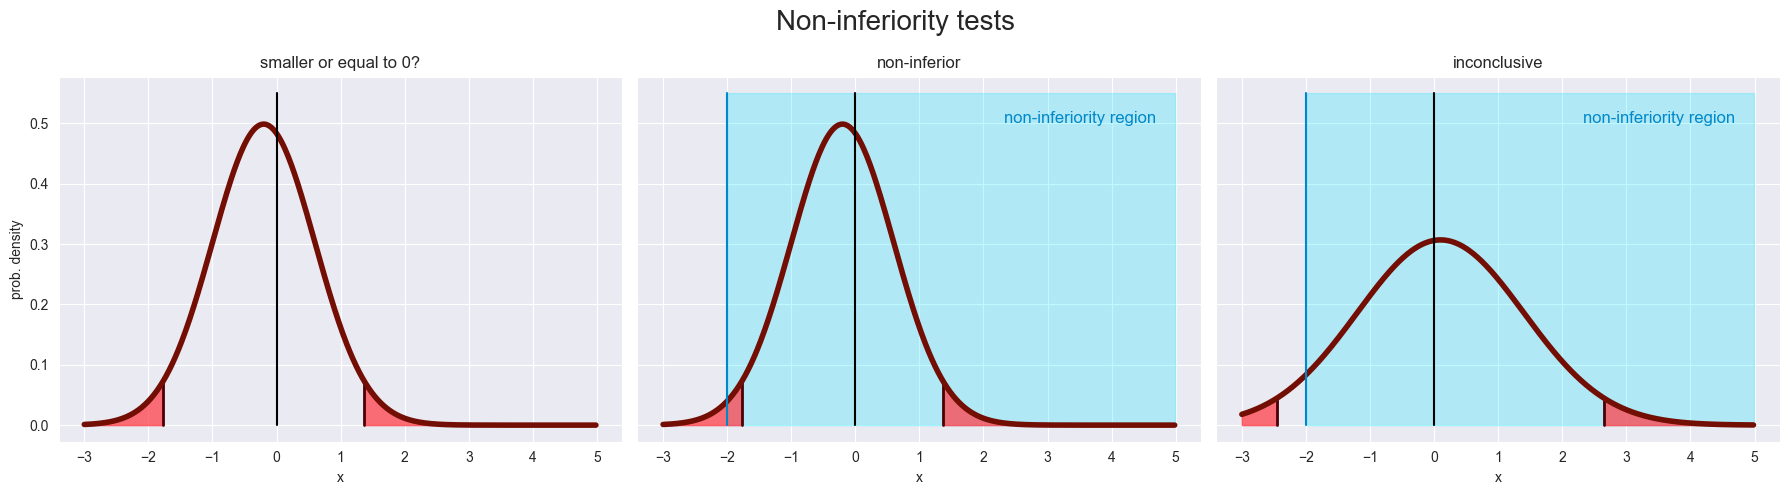

In [143]:
FROM = -3
TO = 5
height = 0.55
margin = -2

# non-inferiority plots
fig, axs = plt.subplots(ncols=3, figsize=(18,5), sharey=True)

# ranges
for i in [1, 2]:
    fill = np.arange(margin, TO, 0.01)
    axs[i].fill_between(fill, [height]*len(fill), color='#06e7ff', alpha=0.25)

# plots
nhst(axs[0], -0.2, 0.8, FROM, TO, title='smaller or equal to 0?')
nhst(axs[1], -0.2, 0.8, FROM, TO, title='non-inferior')
nhst(axs[2],  0.1, 1.3, FROM, TO, title='inconclusive')

# vertical lines at 0
for ax in axs:
    ax.plot(*vline(0, height), c='k')

for i in [1, 2]:
    axs[i].plot(*vline(margin, height), c='#0089ca')
    axs[i].text(TO-0.3, height-0.05, 'non-inferiority region',
                fontsize=12,
                color='#0089ca',
                horizontalalignment='right')

# labels
axs[0].set_ylabel('prob. density')
fig.suptitle('Non-inferiority tests', fontsize=20)

plt.tight_layout()
plt.savefig('examples/non-inf.png', transparent=True, dpi=300)

for i, ax in enumerate(axs):
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f'examples/non-inf_part{i+1}.png', bbox_inches=extent, transparent=True, dpi=300)

plt.show()